

# Acknowledgements and Declarations
I would like to clarify the use of external tools and references in this project. 
I maintained some same variable naming as Ryan et al. (2025)
to get clear communication and direct comparison.


In [1]:
from pathlib import Path
from datetime import datetime
import zipfile
import matplotlib.pyplot as plt
import pandas as pd
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.metrics import (precision_score, recall_score, roc_auc_score, accuracy_score, f1_score) 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Imblearn Pipeline and Resampling
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# XGBoost
from xgboost import XGBClassifier


## Paths

In [2]:
DATA_ZIP = "./data/covid-19-tracker-master/covid-19-tracker-master/data/australia.zip"
DATA_CSV = "./raw_data/australia.csv"
POLICY_CSV = "./data/covid-policy-tracker-master/covid-policy-tracker-master/data/Australia/OxCGRT_AUS_latest.csv"
OUTPUT_DIR = Path("./data/generated_outputs")
MODEL_DIR = Path("./models")
RESULTS_DIR = Path("./results")
FIG_DIR = Path("./figures")
for d in [MODEL_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(exist_ok=True, parents=True)

## Load Australia survey data

In [3]:
def read_australia_csv_from_zip(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path) as z:
        csv_names = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not csv_names:
            raise FileNotFoundError("No CSV found inside australia.zip")
        with z.open(csv_names[0]) as f:
            return pd.read_csv(
                f,
                na_values=[" ", "__NA__"],
                keep_default_na=True,
                low_memory=False,
            )

def load_australia_data() -> pd.DataFrame:
    if Path(DATA_ZIP).exists():
        return read_australia_csv_from_zip(Path(DATA_ZIP))
    if Path(DATA_CSV).exists():
        return pd.read_csv(
            DATA_CSV,
            na_values=[" ", "__NA__"],
            keep_default_na=True,
            low_memory=False,
        )
    raise FileNotFoundError("Could not find australia.zip or australia.csv")

raw_df = load_australia_data()
raw_df.head()

,RecordNo,endtime,qweek,i1_health,i2_health,i7a_health,i3_health,i4_health,i5_health_1,i5_health_2,...,vac_man_99,q_other,household_children_resp,had_covid,vac_boost_beyond,future_1,future_2,had_covid_2,long_covid,future_3
0,0,01/04/2020 16:12,week 1,1.0,1.0,0.0,"No, I have not","No, they have not",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,01/04/2020 16:12,week 1,0.0,6.0,2.0,"No, I have not","No, they have not",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,01/04/2020 16:13,week 1,0.0,0.0,1.0,"No, I have not","Yes, and they have not received their results ...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,01/04/2020 16:16,week 1,2.0,20.0,1.0,"No, I have not","No, they have not",No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,01/04/2020 16:21,week 1,2.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing_table

In [4]:
missing_value_df = pd.DataFrame(
    [(col, raw_df[col].isna().sum()) for col in raw_df.columns],
    columns=["Variable Name", "Missing Value Count"],
).sort_values(by=["Missing Value Count", "Variable Name"]).reset_index(drop=True)

missing_value_df.to_csv(OUTPUT_DIR / "missing_value_counts.csv", index=False)
missing_value_df

,Variable Name,Missing Value Count
0,RecordNo,0
1,age,0
2,employment_status,0
3,endtime,0
4,gender,0
...,...,...
508,V3_me_other,53831
509,V3_baby,53832
510,m6_other,53832
511,V3_baby_other,53833


## Mandate start time
Refer to 3.2.1 Government mandates

In [5]:
policy_df = pd.read_csv(POLICY_CSV)
policy_df = policy_df.loc[:, ["RegionName", "RegionCode", "Date", "H6M_Facial Coverings"]].copy()
policy_df.index = pd.to_datetime(policy_df["Date"], format="%Y%m%d")

#Calculate the 14 day rolling average of each state’s index
rolling_days = 14
df_rolling = policy_df.loc[:, ["RegionName", "H6M_Facial Coverings"]].groupby(
    "RegionName"
).rolling(window=rolling_days).mean()
# When the rolling average of a certain state reached 3 for the first time, it was considered that the jurisdiction had actually entered a stable period of mandatory intervention
mandate_limit = 3
mandate_start_df = df_rolling[df_rolling["H6M_Facial Coverings"] >= mandate_limit].groupby("RegionName").head(1)

mandate_start_df.to_csv(OUTPUT_DIR / "mandate_start_dates.csv")
mandate_start_df

,,H6M_Facial Coverings
RegionName,Date,
Australian Capital Territory,2021-08-18,3.000000
New South Wales,2021-07-09,3.000000
Northern Territory,2021-11-21,3.000000
Queensland,2021-01-17,3.142857
South Australia,2021-07-26,3.000000
Tasmania,2021-10-21,3.000000
Victoria,2020-07-21,3.000000
Western Australia,2021-02-08,3.000000


## Cleaning and Processing
To meet the requirements of the model for input data, this study preprocessed the data based on Ryan et al.'s (2025) method. The specific feature conversion and cleaning steps are divided into eight core steps.
 The number in front of each code cell below indicates the corresponding section number in the report's text description.


During initial Excel observation, two different dash characters were found.
Although the code environment can recognize both, I standardize them to a single format here to avoid potential bugs in downstream processing.

In [6]:
clean_df = raw_df.copy()

def norm_str(ser):
    return ser.astype(str).str.strip()

str_cols = ["r1_1", "r1_2"] + [f"i12_health_{i}" for i in range(1, 26)]
for c in str_cols:
    if c in clean_df.columns:
        clean_df[c] = norm_str(clean_df[c])

### 3.2.2 Removal of High Missing Features
Removal of High Missing Features. Also, I added the week number in this chapter

In [7]:
def convert_datetime(dt):
    if isinstance(dt, (pd.Timestamp, datetime)):
        return dt
    s = str(dt).strip().split()[0]
    return datetime.strptime(s, "%d/%m/%Y")

clean_df["endtime"] = clean_df["endtime"].apply(convert_datetime)

thresh_value = 10781
columns_to_drop = missing_value_df.loc[
    missing_value_df["Missing Value Count"] > thresh_value,
    "Variable Name",
].tolist()
clean_df.drop(columns=columns_to_drop, inplace=True)
start_date = clean_df["endtime"].min()
clean_df["week_number"] = ((clean_df["endtime"] - start_date).dt.days // 14) + 1

### 3.2.3 Repairing Data Gaps Caused by Survey Changes
Regarding the start date for addressing the data gap, following image analysis and personal correspondence with the original author (Ryan), it was confirmed that the February 19th date reported in the original paper was a typographical error. Therefore, February 10th is used as the start date in this analysis.

In [8]:
sdate, edate = "2021-02-10", "2021-10-18" 
consent_gap_mask = (clean_df["endtime"] <= edate) & (clean_df["endtime"] >= sdate)


phq_cols = [f"PHQ4_{i}" for i in range(1, 5)]
d1_cols = [f"d1_health_{i}" for i in list(range(1, 14)) + [98, 99]]
cols_to_fill = phq_cols + d1_cols

clean_df.loc[consent_gap_mask, cols_to_fill] = clean_df.loc[consent_gap_mask, cols_to_fill].fillna("N/A")

### 3.2.4 Processing of Predictive Variables
The core goals of the prediction are "self-protection behavior" and "mask wearing". The original text records the frequency of respondents performing a certain behavior in the past 7 days.

In [9]:
#Convert str to numbers
freq_to_score = {
    "Always": 5, "Frequently": 4, "Sometimes": 3, 
    "Rarely": 2, "Not at all": 1
}

i12_cols = [c for c in clean_df.columns if c.startswith("i12_health_")]
clean_df[i12_cols] = clean_df[i12_cols].replace(freq_to_score)

#Mask wearing behavior
mask_cols = ["i12_health_1", "i12_health_22", "i12_health_23", "i12_health_25"]
clean_df["face_mask_scale"] = clean_df[mask_cols].median(axis=1)
clean_df["face_mask_bi"] = clean_df["face_mask_scale"].apply(
    lambda x: "Yes" if x >= 4 else ("No" if x < 4 else None)
)
#Comprehensive protective behavior
protective_behaviour_cols = [col for col in clean_df.columns if col.startswith("i12_")]
clean_df["protective_behaviour_scale"] = clean_df[protective_behaviour_cols].median(axis=1)
clean_df["protective_behaviour_bi"] = clean_df["protective_behaviour_scale"].apply(
    lambda x: "Yes" if x >= 4 else ("No" if x < 4 else None)
)
#Protective features other than masks
protective_behaviour_nomask_cols = [
    col
    for col in protective_behaviour_cols
    if col not in ["i12_health_1", "i12_health_22", "i12_health_23", "i12_health_25"]
]
clean_df["protective_behaviour_nomask_scale"] = clean_df[
    protective_behaviour_nomask_cols
].median(axis=1)
clean_df["protective_behaviour_nomask_bi"] = clean_df["protective_behaviour_nomask_scale"].apply(
    lambda x: "Yes" if x >= 4 else ("No" if x < 4 else None)
)

C:\Users\ljj15\AppData\Local\Temp\ipykernel_3092\3236983135.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clean_df[i12_cols] = clean_df[i12_cols].replace(freq_to_score)


### 3.2.5 Dimensionality Reduction for Sparse Comorbidity Features
In the raw data, the comorbidities were scattered among 13 binary options (from d1_ health _1 to d1_ health _99), which makes the data extremely sparse. This study removed all specific disease types and made them into a single categorical variable called d1_comorbidities

In [10]:
def comorbidity(row):
    if row["d1_health_99"] == "Yes":
        return "No"
    elif row["d1_health_99"] == "N/A":
        return "N/A"
    elif row["d1_health_98"] == "Yes":
        return "Prefer_not_to_say"
    else:
        return "Yes"

clean_df["comorbidity_status"] = clean_df.apply(comorbidity, axis=1)
d1_cols = [c for c in clean_df.columns if c.startswith("d1_")]
clean_df = clean_df.drop(columns=d1_cols)

### 3.2.6 Processing of Demographic Variables
In order to reduce the effect of extreme values on trees or linear models, this study assigned a value of 8 to all samples with answers of "8 people or more".

In [11]:
household_mapping = {str(i): i for i in range(1, 8)}
household_mapping.update({
    "8 or more": 8, 
    "Prefer not to say": None, 
    "Don't know": None
})

clean_df["household_size"] = clean_df["household_size"].astype(str).str.strip().map(household_mapping)

### 3.2.7 Preprocessing of Perception, Trust, and Mental Health Variables 

In [12]:
# Perception of illness threat
r1_cols = ["r1_1", "r1_2"]
clean_df[r1_cols] = clean_df[r1_cols].replace({
    "7 - Agree": 7, "7 – Agree": 7, 
    "1 - Disagree": 1, "1 – Disagree": 1,
    "6": 6, "5": 5, "4": 4, "3": 3, "2": 2
}).apply(pd.to_numeric, errors="coerce")

clean_df.dropna(inplace=True)

cleaned_data_df = clean_df.drop(["qweek", "weight"] + protective_behaviour_cols, axis=1).copy()
cleaned_data_df.to_csv(OUTPUT_DIR / "cleaned_data.csv", index=False, date_format="%Y-%m-%d")

cleaned_data_df.head()

,RecordNo,endtime,i2_health,i9_health,i11_health,age,gender,state,household_size,employment_status,...,r1_1,r1_2,week_number,face_mask_scale,face_mask_bi,protective_behaviour_scale,protective_behaviour_bi,protective_behaviour_nomask_scale,protective_behaviour_nomask_bi,comorbidity_status
9023,9023,2020-06-24,0.0,Not sure,Not sure,31,Male,Western Australia,1.0,Full time employment,...,5.0,1.0,7,3.0,No,3.0,No,3.0,No,Yes
9024,9024,2020-06-24,2.0,No,Very willing,36,Male,Victoria,4.0,Full time employment,...,6.0,4.0,7,4.0,Yes,3.0,No,3.0,No,No
9025,9025,2020-06-24,6.0,Yes,Very willing,73,Male,Northern Territory,2.0,Retired,...,5.0,6.0,7,1.0,No,4.0,Yes,5.0,Yes,Yes
9026,9026,2020-06-24,20.0,Yes,Somewhat willing,58,Male,Queensland,2.0,Not working,...,1.0,4.0,7,1.0,No,1.0,No,1.0,No,Yes
9027,9027,2020-06-24,0.0,Yes,Very willing,65,Male,Victoria,1.0,Full time employment,...,3.0,1.0,7,1.0,No,1.0,No,1.0,No,No


Use state and response time to merge 'during_mandate' variagbe & convert unordered cate variables into dummy variables

In [13]:
model_df = cleaned_data_df.copy()
mandate_lookup_df = pd.read_csv(OUTPUT_DIR / "mandate_start_dates.csv")
mandate_lookup_df["Date"] = pd.to_datetime(mandate_lookup_df["Date"])
states_date = {}
for state, date in zip(mandate_lookup_df["RegionName"], mandate_lookup_df["Date"]):
    states_date.update({state: [date]})
#merge 'during_mandate'
def mandates_convert(row):
    endtime = pd.to_datetime(row["endtime"])
    state = row["state"]

    if state not in states_date:
        return 0
    if states_date[state][0] <= endtime:
        return 1
    else:
        return 0

model_df["during_mandate"] = model_df.apply(mandates_convert, axis=1)

#All things need to be convert
categorical_features = [
    "PHQ4_1", "PHQ4_2", "PHQ4_3", "PHQ4_4",
    "WCRex1", "WCRex2", 
    "comorbidity_status", 
    "employment_status", 
    "gender", 
    "i11_health", "i9_health", 
    "state"
]

for col in categorical_features:
    dummy = pd.get_dummies(model_df[col], prefix=col, drop_first=True)
    model_df = pd.concat([model_df, dummy], axis=1)
    model_df = model_df.drop(col, axis=1)

model_df.to_csv(OUTPUT_DIR / "processed_data.csv", index=False)
model_df

,RecordNo,endtime,i2_health,age,household_size,cantril_ladder,r1_1,r1_2,week_number,face_mask_scale,...,i11_health_Very willing,i9_health_Not sure,i9_health_Yes,state_New South Wales,state_Northern Territory,state_Queensland,state_South Australia,state_Tasmania,state_Victoria,state_Western Australia
9023,9023,2020-06-24,0.0,31,1.0,8.0,5.0,1.0,7,3.0,...,False,True,False,False,False,False,False,False,False,True
9024,9024,2020-06-24,2.0,36,4.0,8.0,6.0,4.0,7,4.0,...,True,False,False,False,False,False,False,False,True,False
9025,9025,2020-06-24,6.0,73,2.0,8.0,5.0,6.0,7,1.0,...,True,False,True,False,True,False,False,False,False,False
9026,9026,2020-06-24,20.0,58,2.0,8.0,1.0,4.0,7,1.0,...,False,False,True,False,False,True,False,False,False,False
9027,9027,2020-06-24,0.0,65,1.0,7.0,3.0,1.0,7,1.0,...,True,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51826,51826,2022-02-26,6.0,28,5.0,4.0,2.0,2.0,50,4.0,...,False,False,False,True,False,False,False,False,False,False
51827,51827,2022-02-26,4.0,32,6.0,5.0,5.0,6.0,50,4.5,...,False,False,True,True,False,False,False,False,False,False
51828,51828,2022-03-01,3.0,31,1.0,7.0,3.0,5.0,50,5.0,...,True,False,True,False,False,False,False,False,False,False
51829,51829,2022-03-01,10.0,27,4.0,5.0,5.0,3.0,50,2.0,...,False,False,True,True,False,False,False,False,False,False


# Data Splitting 
Firstly, the data was split into training and testing sets in an 80:20 ratio stratified with the value of during_mandate.

In [14]:
split_df = model_df.copy()
split_df["endtime"] = pd.to_datetime(split_df["endtime"])

mandate_period_label = split_df.loc[:, "during_mandate"]

df_train, df_test = train_test_split(
    split_df,
    test_size=0.2,
    random_state=1935487,
    stratify=mandate_period_label,
)

df_train.to_csv(OUTPUT_DIR / "df_train.csv", index=False)
df_test.to_csv(OUTPUT_DIR / "df_test.csv", index=False)

print(df_train.shape, df_test.shape)

(32336, 66) (8084, 66)


# Visualizations of Cleaned Data
#### In this section, I will present several visualizations to illustrate the processed data.

#### Figure1 in paper
This line chart provides a visual summary of the fortnighrly trends in public compliance with protective behaviors from mid-2020 to early 2022.

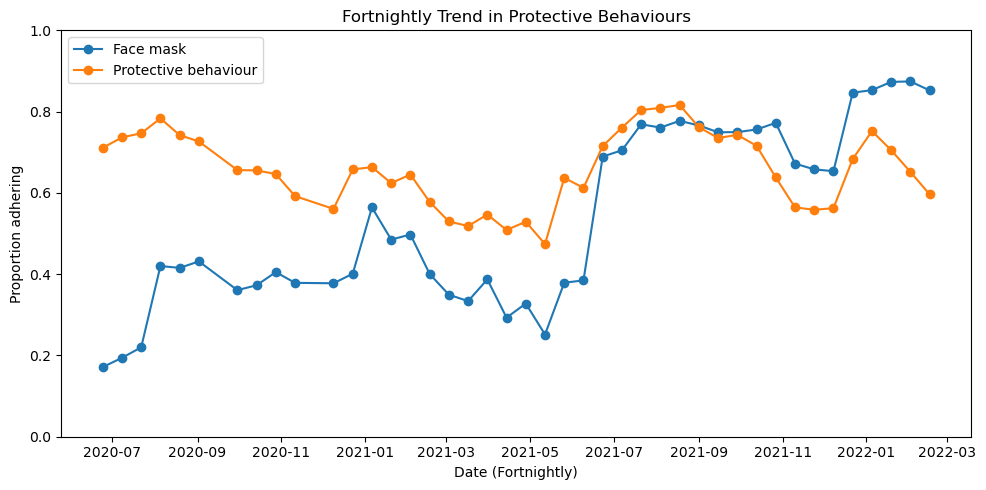

In [15]:
plot_df = model_df.copy()

# Convert categorical binary outcomes to numerical
plot_df["face_mask_yes"] = (plot_df["face_mask_bi"] == "Yes").astype(int)
plot_df["protective_yes"] = (plot_df["protective_behaviour_nomask_bi"] == "Yes").astype(int)

# Calculate the start date for each 14-day window
baseline_date = plot_df["endtime"].min().floor("D")
plot_df["fortnight_start"] = baseline_date + pd.to_timedelta(
    ((plot_df["endtime"] - baseline_date).dt.days // 14) * 14, unit="D"
)

fortnightly_summary = (
    plot_df.groupby("fortnight_start")[["face_mask_yes", "protective_yes"]]
    .mean()
    .reset_index()
)


plt.figure(figsize=(10, 5))
plt.plot(
    fortnightly_summary["fortnight_start"], 
    fortnightly_summary["face_mask_yes"], 
    label="Face mask", 
    marker="o"
)
plt.plot(
    fortnightly_summary["fortnight_start"], 
    fortnightly_summary["protective_yes"], 
    label="Protective behaviour", 
    marker="o"
)

plt.ylabel("Proportion adhering")
plt.xlabel("Date (Fortnightly)")
plt.title("Fortnightly Trend in Protective Behaviours")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

This bar chart illustrates the sample size distribution of the binary indicator during_mandate.

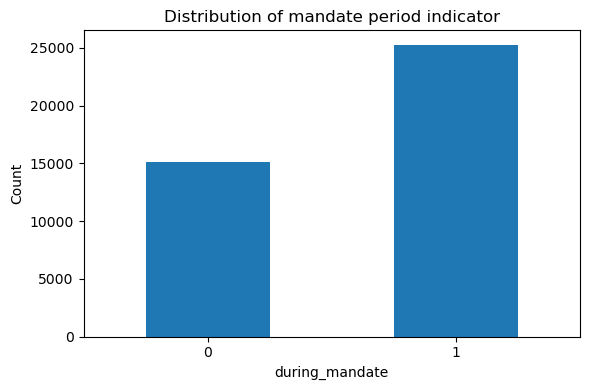

In [16]:
plt.figure(figsize=(6, 4))
plot_df["during_mandate"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of mandate period indicator")
plt.xlabel("during_mandate")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Figure2 in paper
The proportion of respondents frequently wearing face masks before and after the implementation of mask mandates.

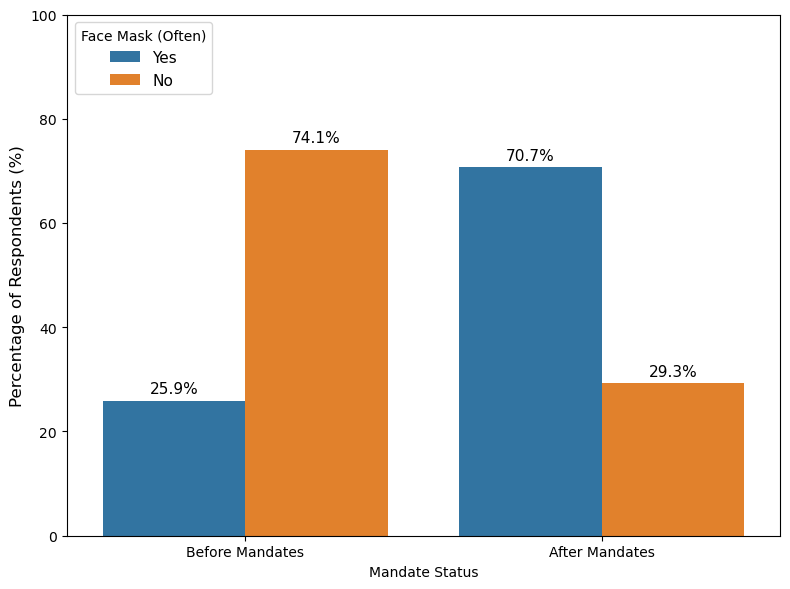

In [17]:
# Prepare data and map labels
plot_df = model_df.copy()
plot_df['Mandate Status'] = plot_df['during_mandate'].map({
    0: 'Before Mandates', 
    1: 'After Mandates'
})

#Calculate percentages
summary_df = (
    plot_df.groupby('Mandate Status')['face_mask_bi']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=summary_df, 
    x='Mandate Status', 
    y='Percentage', 
    hue='face_mask_bi', 
    order=['Before Mandates', 'After Mandates']
)
plt.ylabel('Percentage of Respondents (%)', fontsize=12)
plt.legend(title='Face Mask (Often)', fontsize=11, loc='upper left')
plt.ylim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=11)

plt.tight_layout()
plt.savefig(FIG_DIR / "mask_mandate_impact.png", dpi=300)
plt.show()

This histogram visualizes the temporal distribution of the dataset after splitting it into Training and Testing sets.

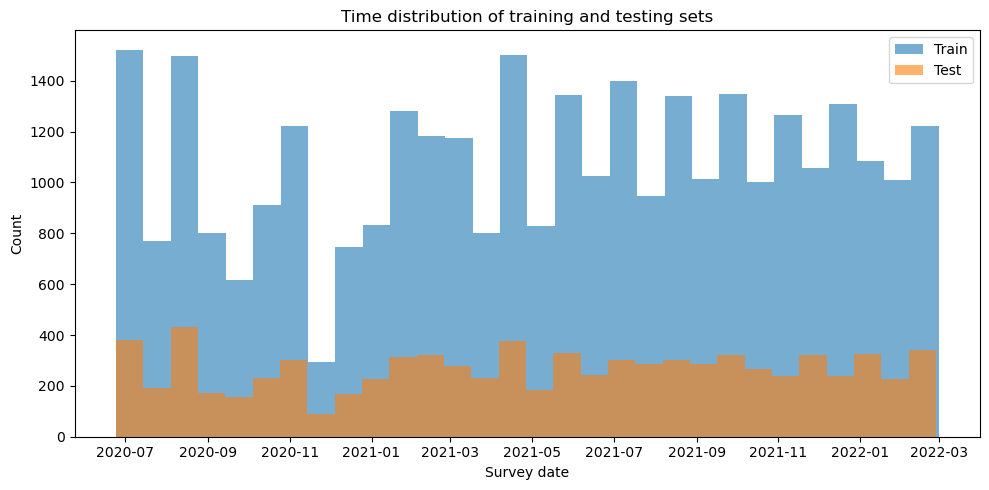

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(df_train["endtime"], bins=30, alpha=0.6, label="Train")
plt.hist(df_test["endtime"], bins=30, alpha=0.6, label="Test")
plt.title("Time distribution of training and testing sets")
plt.xlabel("Survey date")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### 3.3.1 Construction of Predictive Scenarios
To better analyse the impact of mandates on the main driving factors, this study established six independent prediction scenarios.
- 1, Predicting face masks
- 1a, Predicting face masks in early time
- 1b, Predicting face masks in mandate periods
- 2, Predicting protective behaviour
- 2a, Predicting protective behaviour in early time
- 2b, Predicting protective behaviour in mandate periods

In [19]:
# These are metadata, scales used to derive targets, or the mandate itself.
base_exclude = [
    "RecordNo", 
    "face_mask_scale", 
    "protective_behaviour_scale",
    "endtime", 
    "during_mandate",
    "protective_behaviour_nomask_bi"
]


#  Fit the encoder once on the full set of possible labels.
label_encoder = LabelEncoder()
label_encoder.fit(["No", "Yes"])
print(f"Fixed Label Mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

model_configs = {
    "1":  {"target": "face_mask_bi",           "mandate_filter": None},
    "1a": {"target": "face_mask_bi",           "mandate_filter": 0},
    "1b": {"target": "face_mask_bi",           "mandate_filter": 1},
    "2":  {"target": "protective_behaviour_bi", "mandate_filter": None},
    "2a": {"target": "protective_behaviour_bi", "mandate_filter": 0},
    "2b": {"target": "protective_behaviour_bi", "mandate_filter": 1},
}


for mod_name, config in model_configs.items():
    target_col = config["target"]
    m_filter = config["mandate_filter"]
    
    if m_filter is not None:
        train_sub = df_train[df_train["during_mandate"] == m_filter].copy()
        test_sub  = df_test[df_test["during_mandate"] == m_filter].copy()
    else:
        train_sub = df_train.copy()
        test_sub  = df_test.copy()
    

    
    all_potential_targets = ["face_mask_bi", "protective_behaviour_bi"]
    current_drop_cols = list(set(base_exclude + all_potential_targets))
    
    # We must only drop protective_behaviour_nomask_scale in protective behaviours serious. 
    if "protective_behaviour_bi" in config["target"]:
        current_drop_cols.append("protective_behaviour_nomask_scale")
        
    X_train = train_sub.drop(columns=[c for c in current_drop_cols if c in train_sub.columns])
    X_test  = test_sub.drop(columns=[c for c in current_drop_cols if c in test_sub.columns])
    
    y_train = label_encoder.transform(train_sub[target_col])
    y_test  = label_encoder.transform(test_sub[target_col])
    
    X_train.to_csv(OUTPUT_DIR / f"X_train_model_{mod_name}.csv", index=False)
    X_test.to_csv(OUTPUT_DIR / f"X_test_model_{mod_name}.csv", index=False)
    pd.DataFrame({"y_train": y_train}).to_csv(OUTPUT_DIR / f"y_train_model_{mod_name}.csv", index=False)
    pd.DataFrame({"y_test": y_test}).to_csv(OUTPUT_DIR / f"y_test_model_{mod_name}.csv", index=False)

Fixed Label Mapping: {'No': 0, 'Yes': 1}


### 3.3.3 Cross Validation
This chunk defines the merics and cross validation mechanism.

In [20]:
METRIC_LIST = ['precision', 'recall', 'roc_auc', 'accuracy', 'f1']
SEED = 1935487
cv_strategy = StratifiedShuffleSplit(n_splits=5, test_size=1/5, random_state=SEED)

MODEL_NUMBERS = ["model_1", "model_1a", "model_1b", "model_2", "model_2a", "model_2b"]
display_models = ["model_1a", "model_1b", "model_2a", "model_2b"]


## Modelling

The next chunk constructs an imblearn pipeline, performs GridSearchCV with automated oversampling, and saves the final refitted model on AUC.

In [21]:
def run_model(model_number, model_type, clf, param_grid):

    print(f"Processing: {model_number} | Algorithm: {model_type}")
    
    # Load training data
    X_train = pd.read_csv(OUTPUT_DIR / f"X_train_{model_number}.csv", keep_default_na=False)
    y_train = pd.read_csv(OUTPUT_DIR / f"y_train_{model_number}.csv", keep_default_na=False).values.ravel()
    
    pipeline = ImbPipeline([
        ('sampler', RandomOverSampler(random_state=SEED)),
        ('classifier', clf)
    ])
    grid_params = {f"classifier__{k}": v for k, v in param_grid.items()}
    
    grid_search = GridSearchCV(
        pipeline, 
        param_grid=grid_params, 
        cv=cv_strategy, 
        scoring=METRIC_LIST, 
        refit='roc_auc', 
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Extract performance metrics for the best model index
    best_idx = grid_search.best_index_
    best_params = grid_search.best_params_
    
    def get_mean_se_string(metric):
        mean_val = grid_search.cv_results_[f'mean_test_{metric}'][best_idx]
        std_val = grid_search.cv_results_[f'std_test_{metric}'][best_idx]
        se_val = std_val / np.sqrt(cv_strategy.get_n_splits())
        return f"{mean_val:.3f} ({se_val:.3f})"
    
    metrics = {
        "model_number": model_number,
        "model_type": model_type,
        "roc_auc": get_mean_se_string('roc_auc'),
        "precision": get_mean_se_string('precision'),
        "recall": get_mean_se_string('recall'),
        "accuracy": get_mean_se_string('accuracy'),
        "f1": get_mean_se_string('f1')
    }
    clean_params = {k.replace('classifier__', ''): v for k, v in best_params.items()}
    print(f" Best Params:    {clean_params}")
    print(f" Mean ROC AUC:   {metrics['roc_auc']}")
    
    with open(RESULTS_DIR / f"{model_number}_{model_type}.pkl", "wb") as f:
        pickle.dump(grid_search.cv_results_, f)
        
    with open(MODEL_DIR / f"{model_number}_{model_type}_final.pkl", "wb") as f:
        pickle.dump(grid_search.best_estimator_, f)
        
    return metrics

### Grid search settings

In [22]:
# Logistic Regression (regularization strength)
grid_lr = {
    'C': [0.1, 1.0, 10.0]
}

# Decision Tree (maximum depth, minimum samples per leaf, minimum samples to split a node)
grid_dt = {
    'max_depth': [5, 10, 15, None], 
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Random Forest (number of trees, maximum depth, number of features per split)
grid_rf = {
    'n_estimators': [100, 250, 500], 
    'max_depth': [10, 20, None], 
    'max_features': ['sqrt', 'log2']
}

# XGBoost (learning rate, number of trees, maximum depth, number of features per split)
grid_xgb = {
    'learning_rate': [0.05, 0.1, 0.2], 
    'n_estimators': [100, 250, 500], 
    'max_depth': [4, 6, 8], 
    'colsample_bytree': [0.6, 0.8, 1.0]     
}

## Tuning

In [23]:
all_results = []
for m_num in MODEL_NUMBERS:
    
    lr_res = run_model(m_num, "logistic_reg", LogisticRegression(max_iter=5000, random_state=1935487), grid_lr)
    all_results.append(lr_res)
    
    dt_res = run_model(m_num, "binary_tree", DecisionTreeClassifier(random_state=1935487), grid_dt)
    all_results.append(dt_res)
    
    rf_res = run_model(m_num, "rf", RandomForestClassifier( bootstrap=True, random_state=1935487), grid_rf)
    all_results.append(rf_res)
    
    xgb_res = run_model(m_num, "xgboost", XGBClassifier( objective="binary:logistic", random_state=1935487), grid_xgb)
    all_results.append(xgb_res)

final_df = pd.DataFrame(all_results)
final_df.to_csv(RESULTS_DIR / "final_all_models_gridsearch_metrics.csv", index=False)


Processing: model_1 | Algorithm: logistic_reg
 Best Params:    {'C': 0.1}
 Mean ROC AUC:   0.860 (0.002)
Processing: model_1 | Algorithm: binary_tree
 Best Params:    {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
 Mean ROC AUC:   0.885 (0.002)
Processing: model_1 | Algorithm: rf
 Best Params:    {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 500}
 Mean ROC AUC:   0.908 (0.001)
Processing: model_1 | Algorithm: xgboost
 Best Params:    {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 250}
 Mean ROC AUC:   0.918 (0.002)
Processing: model_1a | Algorithm: logistic_reg
 Best Params:    {'C': 0.1}
 Mean ROC AUC:   0.816 (0.004)
Processing: model_1a | Algorithm: binary_tree
 Best Params:    {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
 Mean ROC AUC:   0.811 (0.003)
Processing: model_1a | Algorithm: rf
 Best Params:    {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 500}
 Mean ROC AUC:   0.853 (0.004)


### View of All Models‘ performance after cross-validation


In [33]:
from IPython.display import display

csv_path = RESULTS_DIR / "final_all_models_gridsearch_metrics.csv"

df = pd.read_csv(csv_path)
model_titles = {
    'model_1a': 'Face mask behaviour before mandates',
    'model_1b': 'Face mask behaviour during mandates',
    'model_2a': 'General protective behaviour before mandates',
    'model_2b': 'General protective behaviour during mandates'
}
    
    #Filter out model_1 and model_2 by only keeping the keys in model_titles
df_filtered = df[df['model_number'].isin(model_titles.keys())].copy()
    
if not df_filtered.empty:
    df_filtered['Scenario'] = df_filtered['model_number'].map(model_titles)
    cols_to_keep = ['Scenario', 'model_type', 'roc_auc', 'precision', 'recall', 'accuracy', 'f1']
    df_final = df_filtered[cols_to_keep].copy()
    df_final['model_type'] = df_final['model_type'].replace({
            'logistic_reg': 'Logistic regression', 
            'binary_tree': 'Decision tree', 
            'rf': 'Random forest', 
            'xgboost': 'XGBoost'
        })
        
    numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns
    df_final[numeric_cols] = df_final[numeric_cols].round(3)
        
    df_final.columns = ['Scenario', 'Algorithm', 'AUC', 'Precision', 'Recall', 'Accuracy', 'F1 score']
        
     #Sort values to group them neatly by Scenario and Algorithm, then reset index
    df_final = df_final.sort_values(by=['Scenario', 'Algorithm']).reset_index(drop=True)
    display(df_final)

,Scenario,Algorithm,AUC,Precision,Recall,Accuracy,F1 score
0,Face mask behaviour before mandates,Decision tree,0.811 (0.003),0.476 (0.006),0.773 (0.011),0.718 (0.006),0.589 (0.003)
1,Face mask behaviour before mandates,Logistic regression,0.816 (0.004),0.480 (0.004),0.753 (0.007),0.723 (0.003),0.587 (0.005)
2,Face mask behaviour before mandates,Random forest,0.853 (0.004),0.662 (0.009),0.570 (0.008),0.812 (0.004),0.613 (0.008)
3,Face mask behaviour before mandates,XGBoost,0.855 (0.005),0.606 (0.008),0.664 (0.008),0.800 (0.005),0.634 (0.008)
4,Face mask behaviour during mandates,Decision tree,0.848 (0.002),0.880 (0.001),0.828 (0.005),0.799 (0.003),0.853 (0.003)
5,Face mask behaviour during mandates,Logistic regression,0.836 (0.001),0.880 (0.001),0.777 (0.002),0.768 (0.001),0.826 (0.001)
6,Face mask behaviour during mandates,Random forest,0.890 (0.002),0.879 (0.002),0.914 (0.002),0.851 (0.002),0.896 (0.001)
7,Face mask behaviour during mandates,XGBoost,0.897 (0.002),0.901 (0.002),0.873 (0.003),0.843 (0.003),0.887 (0.002)
8,General protective behaviour before mandates,Decision tree,0.729 (0.004),0.691 (0.005),0.698 (0.012),0.674 (0.003),0.694 (0.005)
9,General protective behaviour before mandates,Logistic regression,0.731 (0.003),0.686 (0.002),0.692 (0.002),0.669 (0.002),0.689 (0.002)


#### Final Evaluation on Independent Test Set

In [25]:

test_metrics = []
    # Dictionary to map model IDs to proper titles
model_titles = {
        '1a': 'Face mask behaviour before mandates',
        '1b': 'Face mask behaviour during mandates',
        '2a': 'General protective behaviour before mandates',
        '2b': 'General protective behaviour during mandates'
    }
for mod_name in ["1a", "1b", "2a", "2b"]:
    # Load true test data
    X_test = pd.read_csv(OUTPUT_DIR / f"X_test_model_{mod_name}.csv", keep_default_na=False)
    y_test = pd.read_csv(OUTPUT_DIR / f"y_test_model_{mod_name}.csv").values.ravel()
    
    for algo in ["rf", "xgboost"]:
        with open(MODEL_DIR / f"model_{mod_name}_{algo}_final.pkl", "rb") as f:
            pipeline = pickle.load(f)
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        
        test_metrics.append({
            "Scenario": model_titles.get(mod_name),
            "Algorithm": algo.upper(),
            "AUC": roc_auc_score(y_test, y_prob),
            "precission": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred)
        })

final_test_df = pd.DataFrame(test_metrics).round(3)
display(final_test_df)

,Scenario,Algorithm,AUC,precission,Recall,Accuracy,F1
0,Face mask behaviour before mandates,RF,0.863,0.652,0.613,0.819,0.632
1,Face mask behaviour before mandates,XGBOOST,0.863,0.603,0.711,0.808,0.653
2,Face mask behaviour during mandates,RF,0.882,0.874,0.918,0.847,0.895
3,Face mask behaviour during mandates,XGBOOST,0.885,0.894,0.882,0.841,0.888
4,General protective behaviour before mandates,RF,0.793,0.724,0.751,0.717,0.737
5,General protective behaviour before mandates,XGBOOST,0.792,0.737,0.745,0.724,0.741
6,General protective behaviour during mandates,RF,0.841,0.849,0.887,0.802,0.868
7,General protective behaviour during mandates,XGBOOST,0.849,0.877,0.837,0.796,0.857


## Plotting configuration

In [26]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 14,             
    'axes.labelsize': 16,       
    'axes.titlesize': 18,        
    'xtick.labelsize': 12,
    'ytick.labelsize': 12, 
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'figure.titlesize': 20, 
    'figure.dpi': 300
})


## Plotting definations

This chunk sets up all the labels and colours.
To ensure comparability with Ryan et al.(2025), the color palette used here closely matches the original paper.

In [27]:
#Def feature name
def format_feature_name(raw_name):
    exact_mapping = {
        'protective_behaviour_nomask_scale': 'Protective Behaviour',
        'week_number': 'Week Number',
        'age': 'Age',
        'household_size': 'Household Size',
        'cantril_ladder': 'Cantril Ladder',
        'r1_1': 'Perceived Susceptibility',
        'r1_2': 'Perceived Severity',
        'i2_health': 'Non-Household Contacts',
        'during_mandate': 'Mandate Period'
    }
    if raw_name in exact_mapping:
        return exact_mapping[raw_name]

    prefix_mapping = {
        'gender_': 'Gender',
        'employment_status_': 'Employment Status',
        'WCRex1_': 'Government Handling',
        'WCRex2_': 'Confidence in response',
        'i9_health_': 'Isolate If Unwell',
        'i11_health_': 'Willingness To Isolate',
        'PHQ4_1_': 'Little interest or pleasure',
        'PHQ4_2_': 'Feeling down or depressed',
        'PHQ4_3_': 'Feeling nervous or anxious',
        'PHQ4_4_': 'Worrying',
        'd1_comorbidities_': 'Comorbidities'
    }
    for prefix, clean_base in prefix_mapping.items():
        if raw_name.startswith(prefix):
            suffix = raw_name[len(prefix):]
            return f"{clean_base} ({suffix})"
    return raw_name

#Category colour settings(colour codes was extracted helped by AI tools)
CATEGORY_COLORS = {
    'Self protective behaviours': '#14649c',      
    'Demographics': '#7eb2d4',                    
    'Health, mental health and wellbeing': '#9e9e9e', 
    'Perception of illness threat': '#c2b6a7',    
    'Time': '#df8435',                            
    'Trust in government': '#ac6224',             
    'Unknown': '#333333'                          
}
#Def feature category
def get_feature_category(clean_name):
    category_map = {
        'Protective Behaviour': 'Self protective behaviours',
        'Non-Household Contacts': 'Self protective behaviours',
        'Isolate If Unwell': 'Self protective behaviours',
        'Willingness To Isolate': 'Self protective behaviours',
        'Face Mask Behaviour': 'Self protective behaviours',
        
        'Age': 'Demographics',
        'Gender': 'Demographics',
        'Household Size': 'Demographics',
        'Employment Status': 'Demographics',
        
        'Cantril Ladder': 'Health, mental health and wellbeing',
        'Little interest or pleasure': 'Health, mental health and wellbeing',
        'Feeling down or depressed': 'Health, mental health and wellbeing',
        'Feeling nervous or anxious': 'Health, mental health and wellbeing',
        'Worrying': 'Health, mental health and wellbeing',
        'Comorbidities': 'Health, mental health and wellbeing',
        
        'Week Number': 'Time',
        'Mandate Period': 'Time',
        
        'Government Handling': 'Trust in government',
        'Confidence in response': 'Trust in government',
        
        'Perceived Susceptibility': 'Perception of illness threat',
        'Perceived Severity': 'Perception of illness threat'
    }
    base_name = clean_name.split(' (')[0]
    return category_map.get(base_name, 'Unknown')

#Get feature importance from models
def get_feature_importances(model_number, model_type):
    model_path = MODEL_DIR / f"{model_number}_{model_type}_final.pkl"
    if not model_path.exists():
        print(f"Warning: Model not found at {model_path}")
        return None
        
    with open(model_path, "rb") as f:
        pipeline = pickle.load(f) 
        
    X_train = pd.read_csv(OUTPUT_DIR / f"X_train_{model_number}.csv", keep_default_na=False)
    clf_step = pipeline.named_steps['classifier']
    importances = clf_step.feature_importances_
    
    df_imp = pd.DataFrame({
        'RawFeature': X_train.columns,
        'Importance': importances
    })
    
    df_imp = df_imp[~df_imp['RawFeature'].str.lower().str.startswith('state_')]
    df_imp['Feature'] = df_imp['RawFeature'].apply(format_feature_name)
    
    return df_imp


### Feature Importance Comparisons
These plots are used for visualising how the drivers of compliance shift when mandates drop. left side shows feature importance before mandates, right side is after. the colours group the features, and helps us figure out what actually drives people's decisions when the rules change. , I do used AI tools to extract the specific colour codes from Ryan et al.'s (2025) research for the feature importance figures to directly compare.

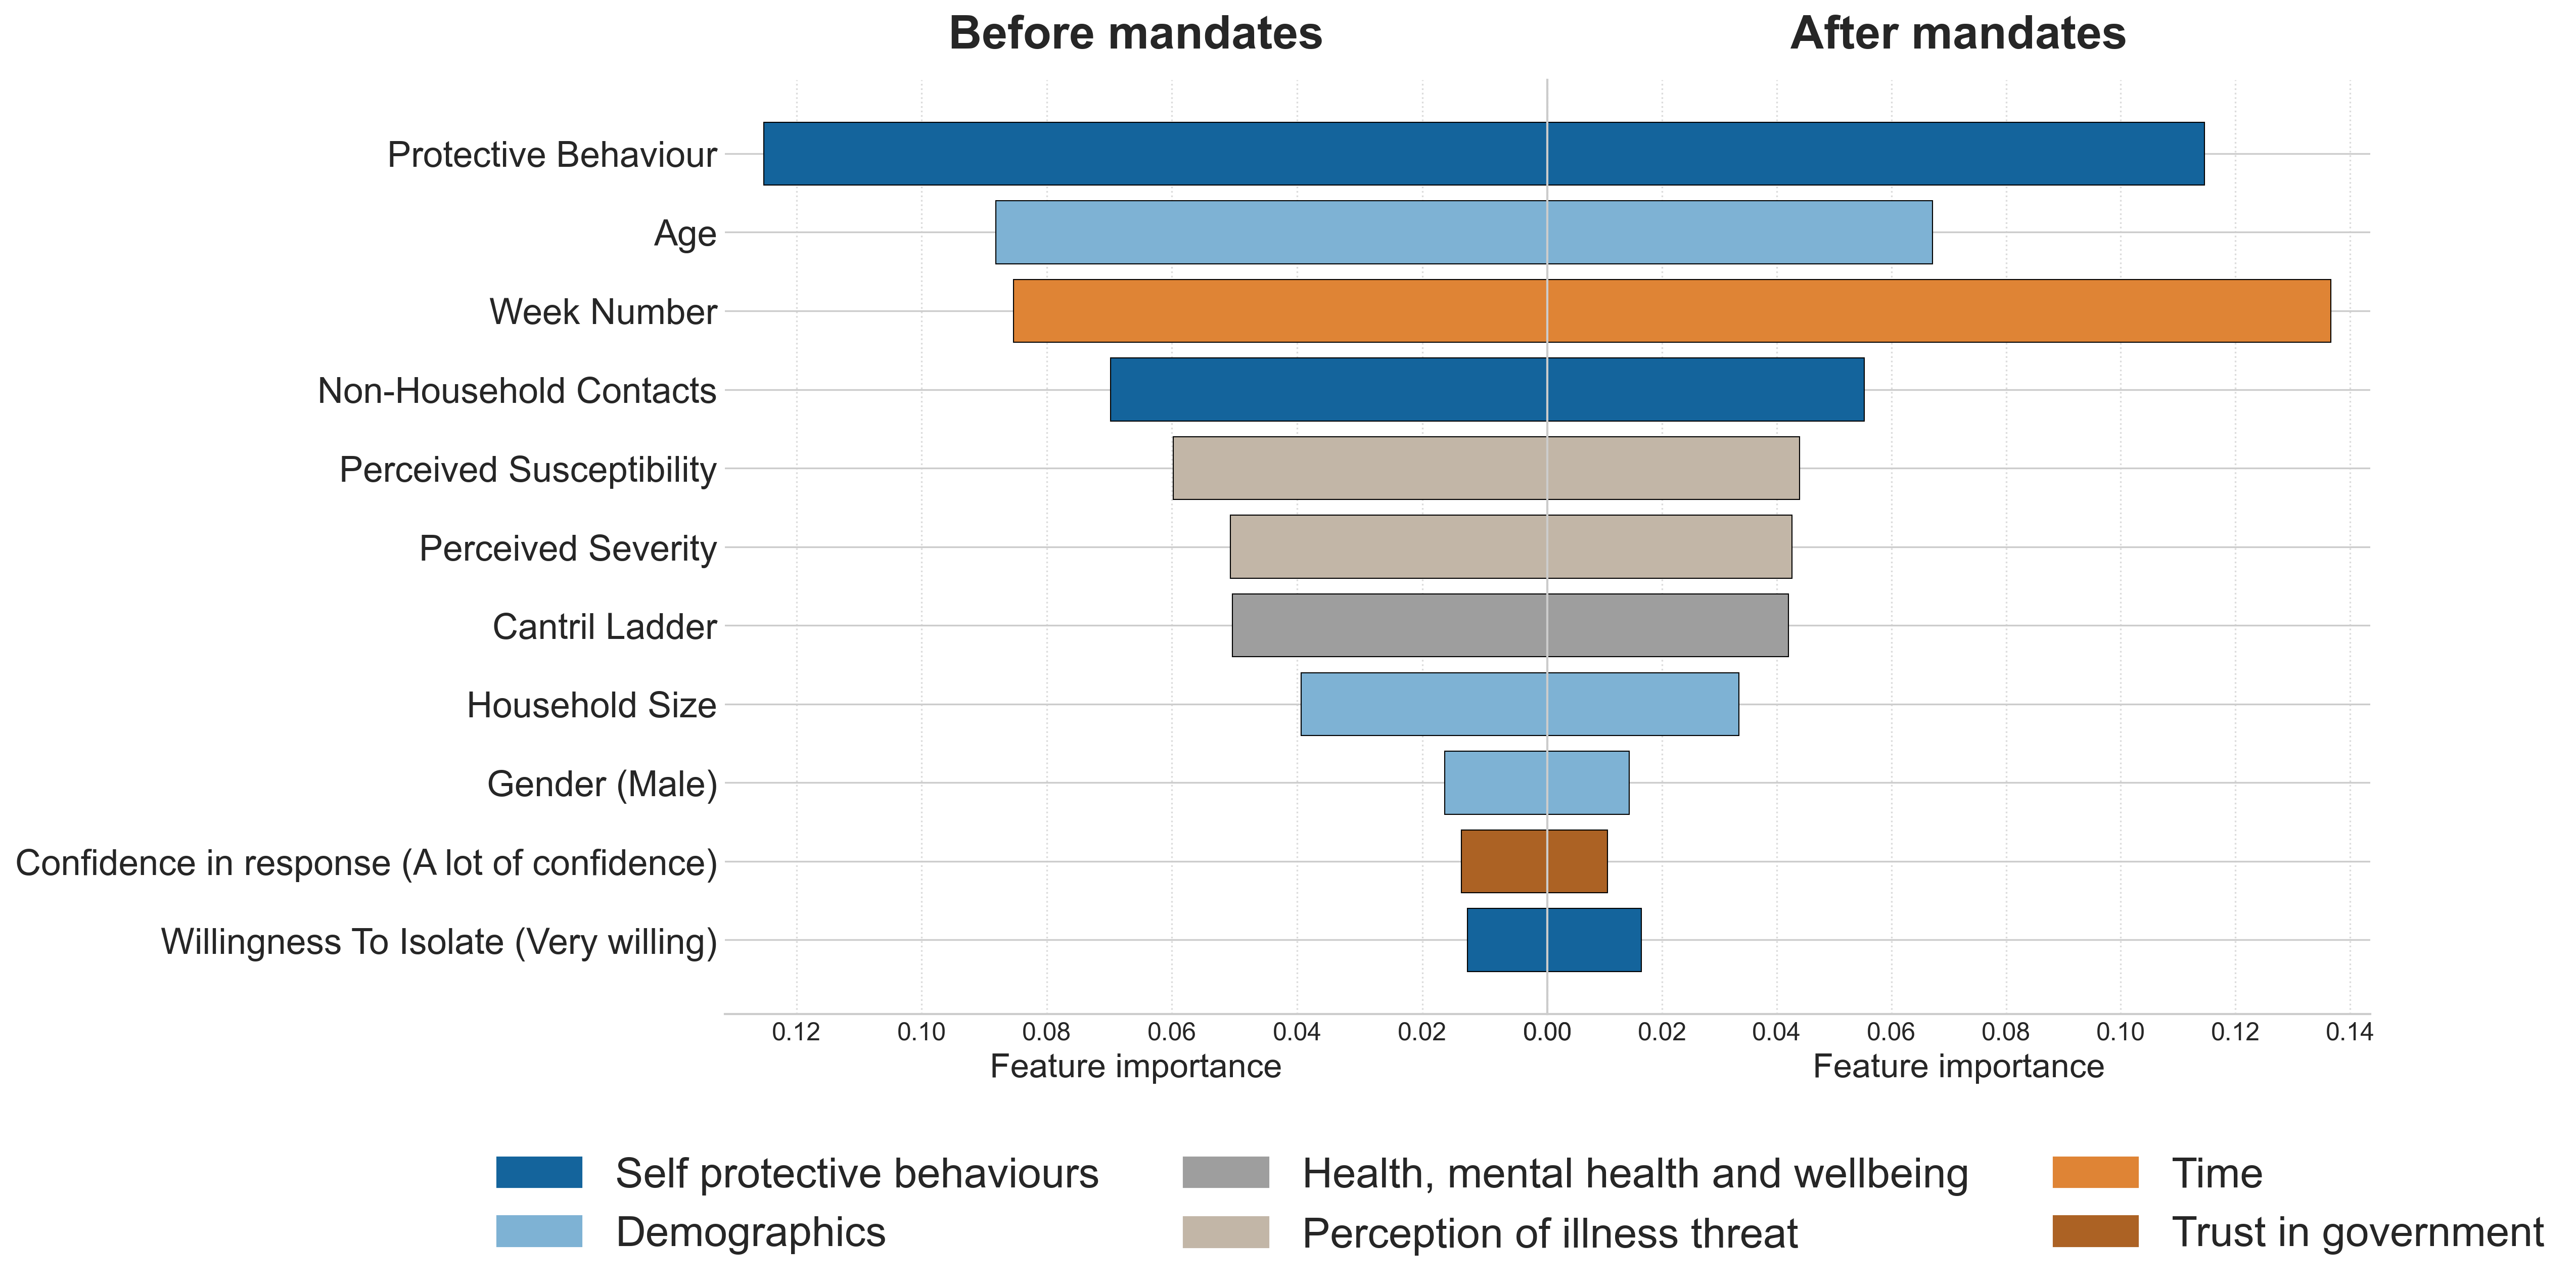

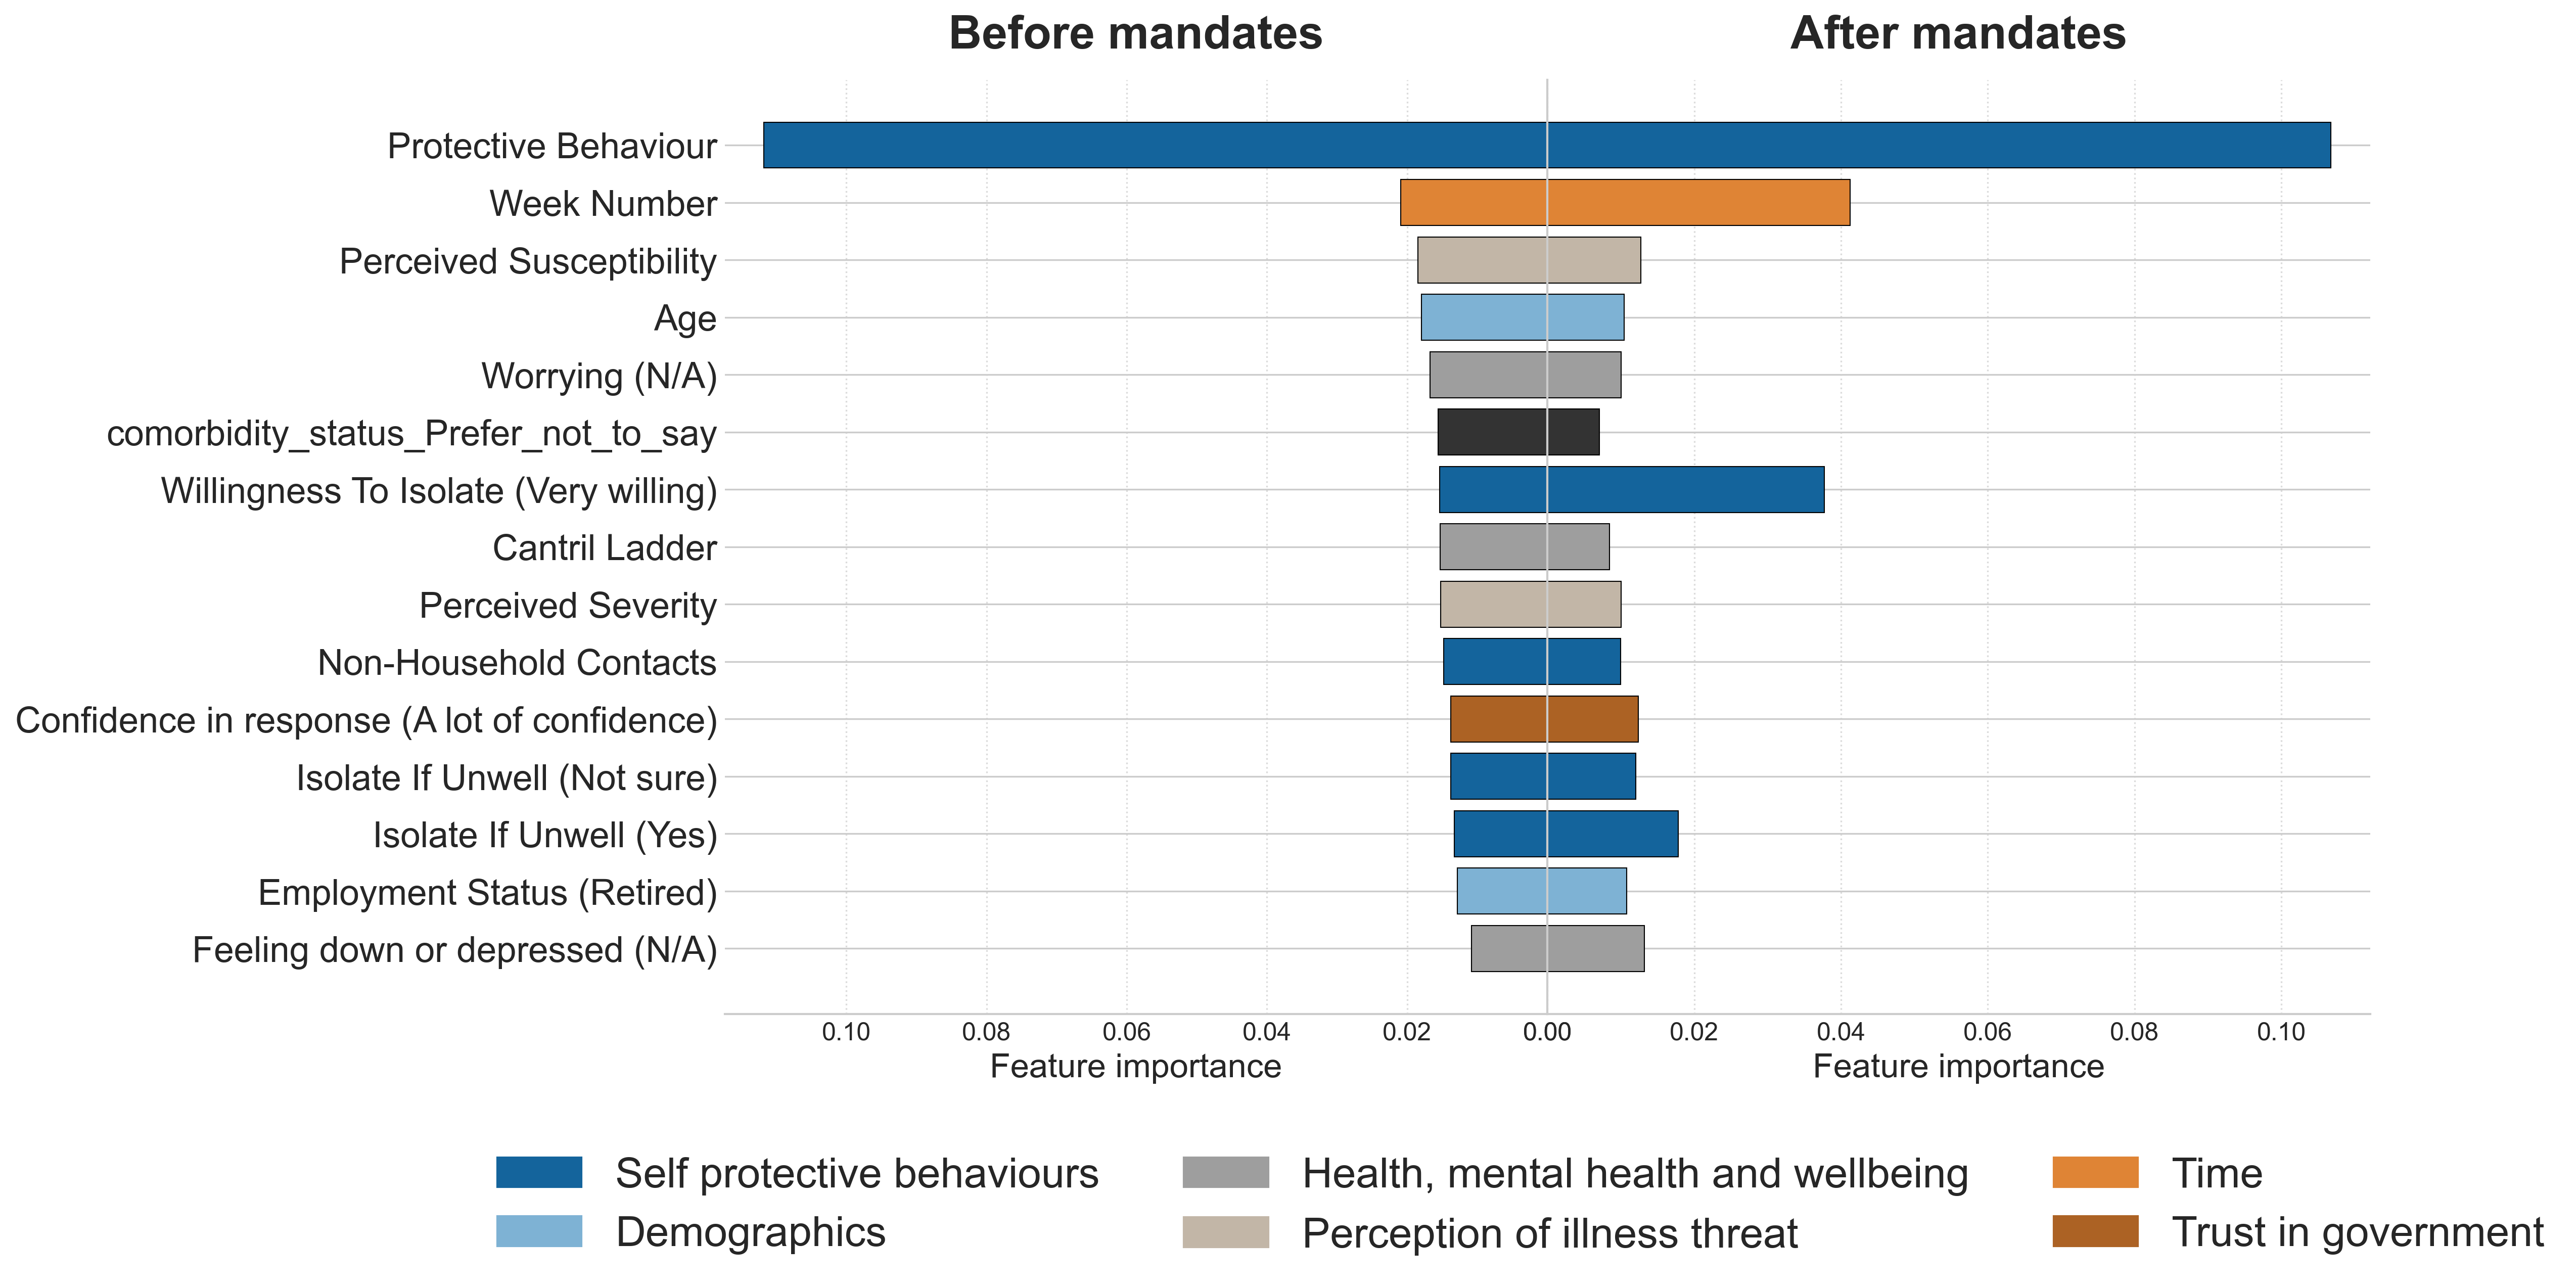

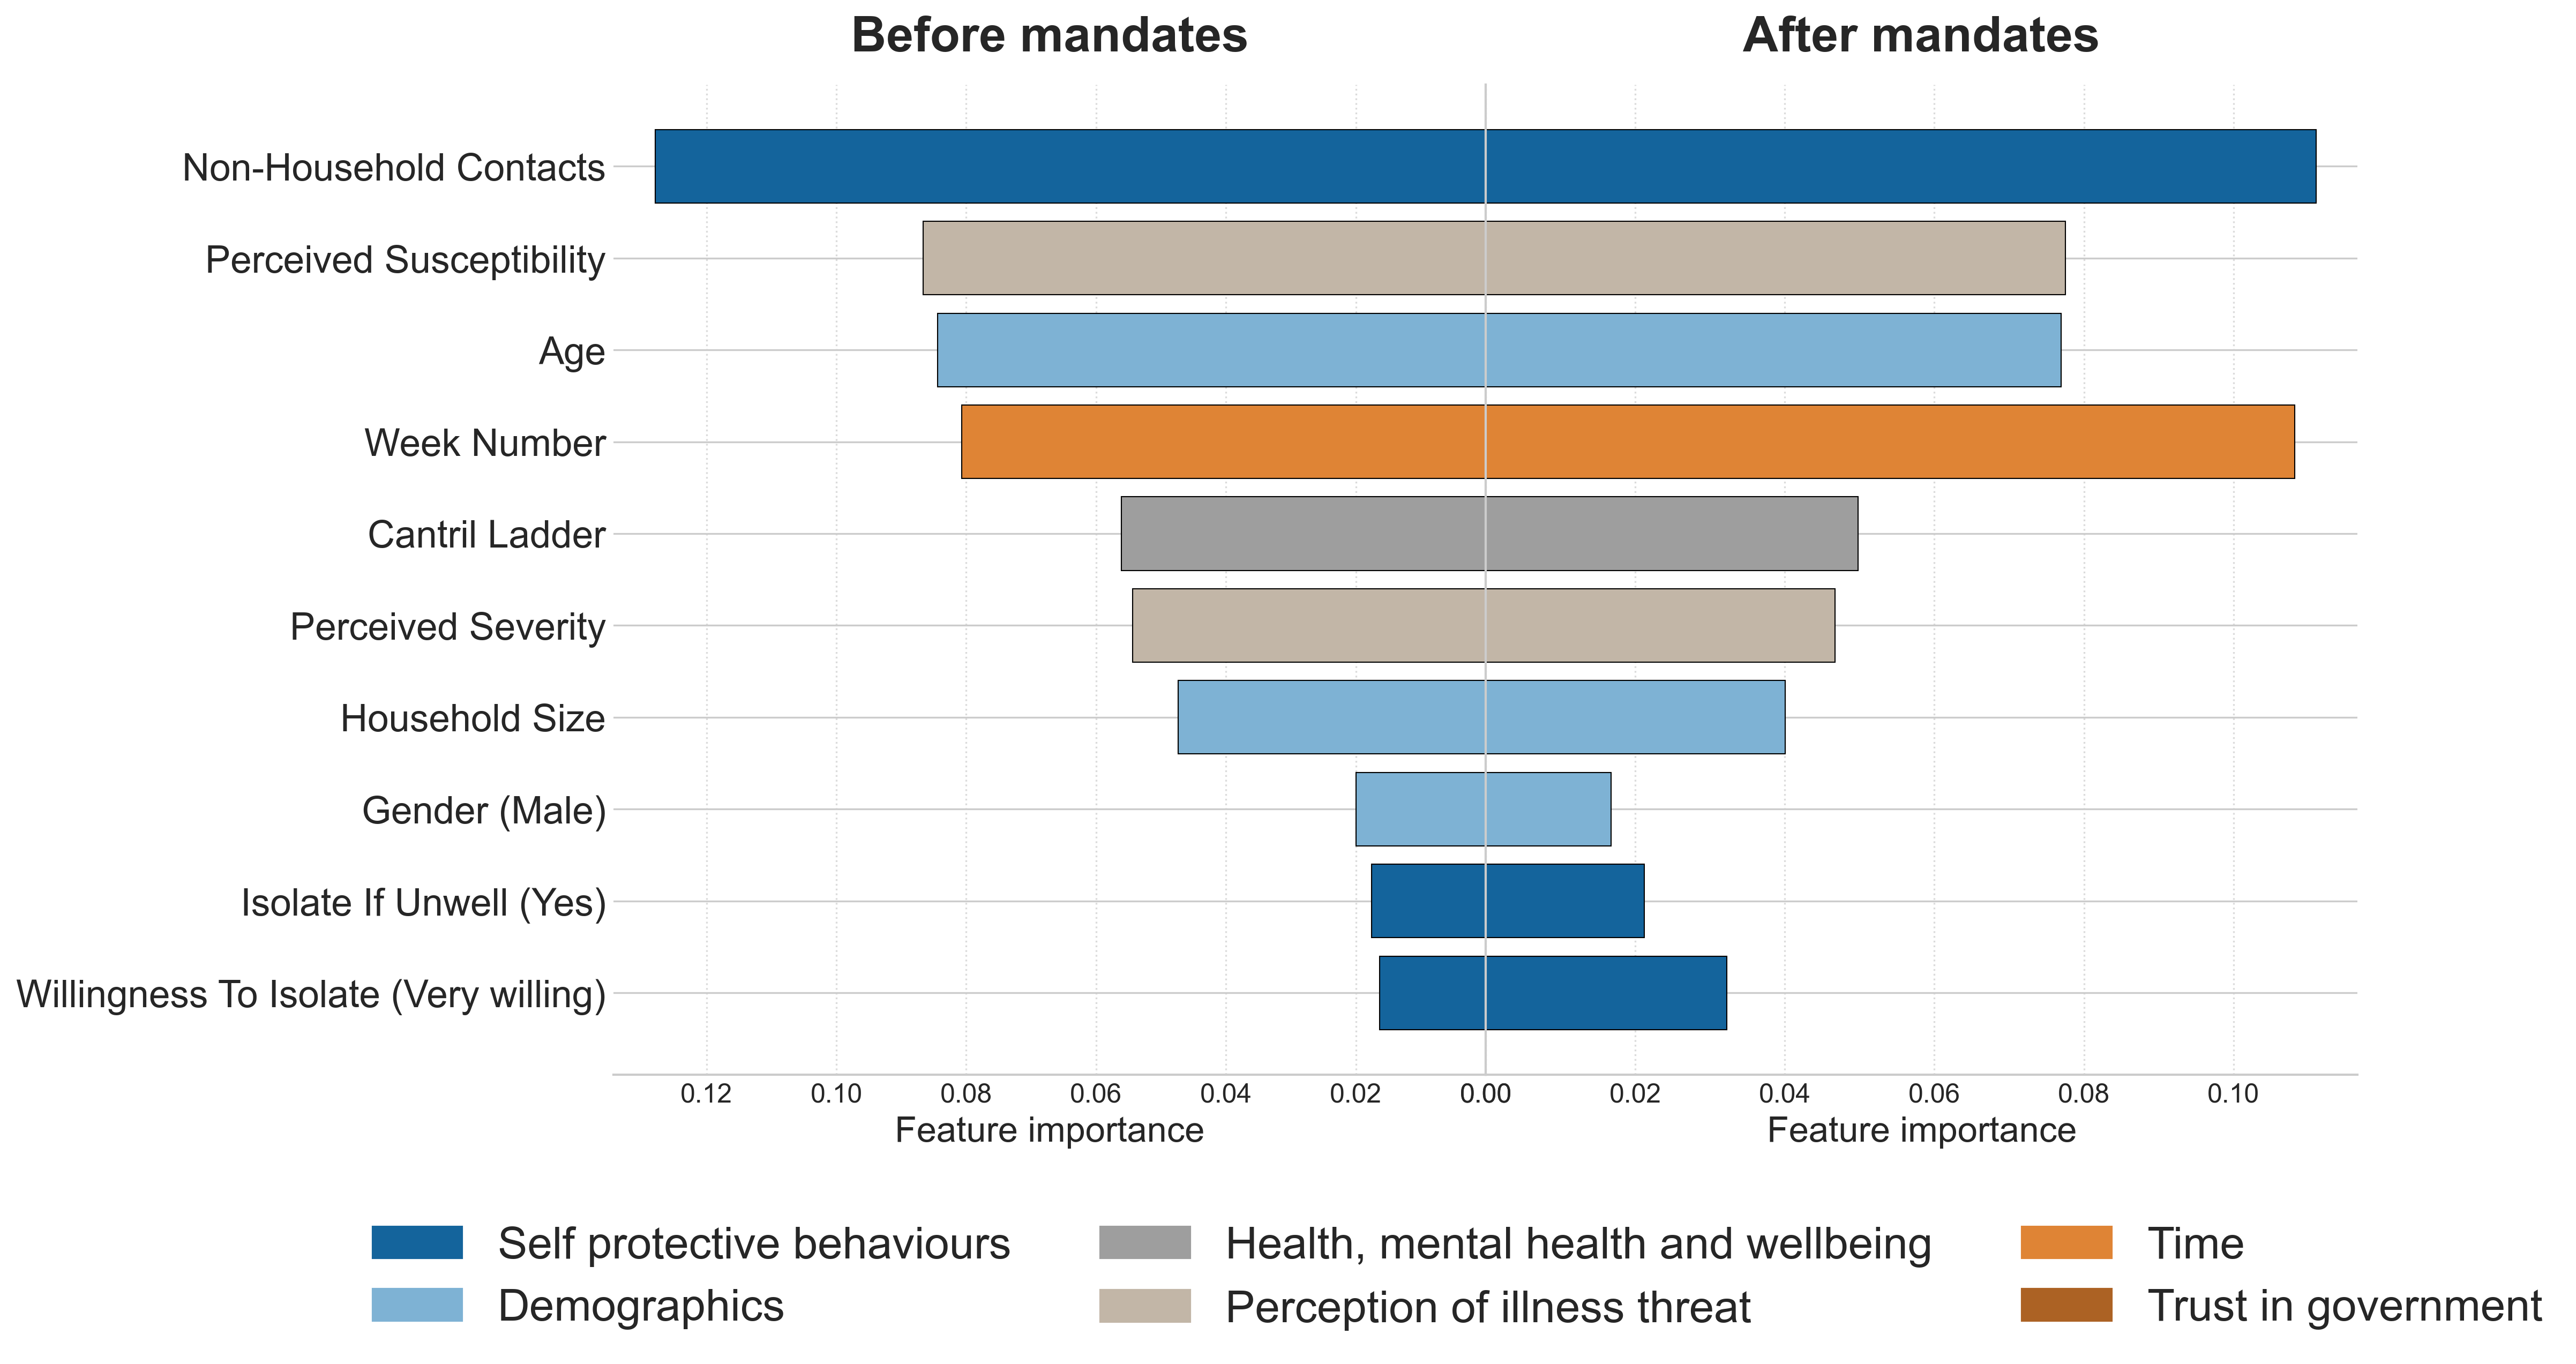

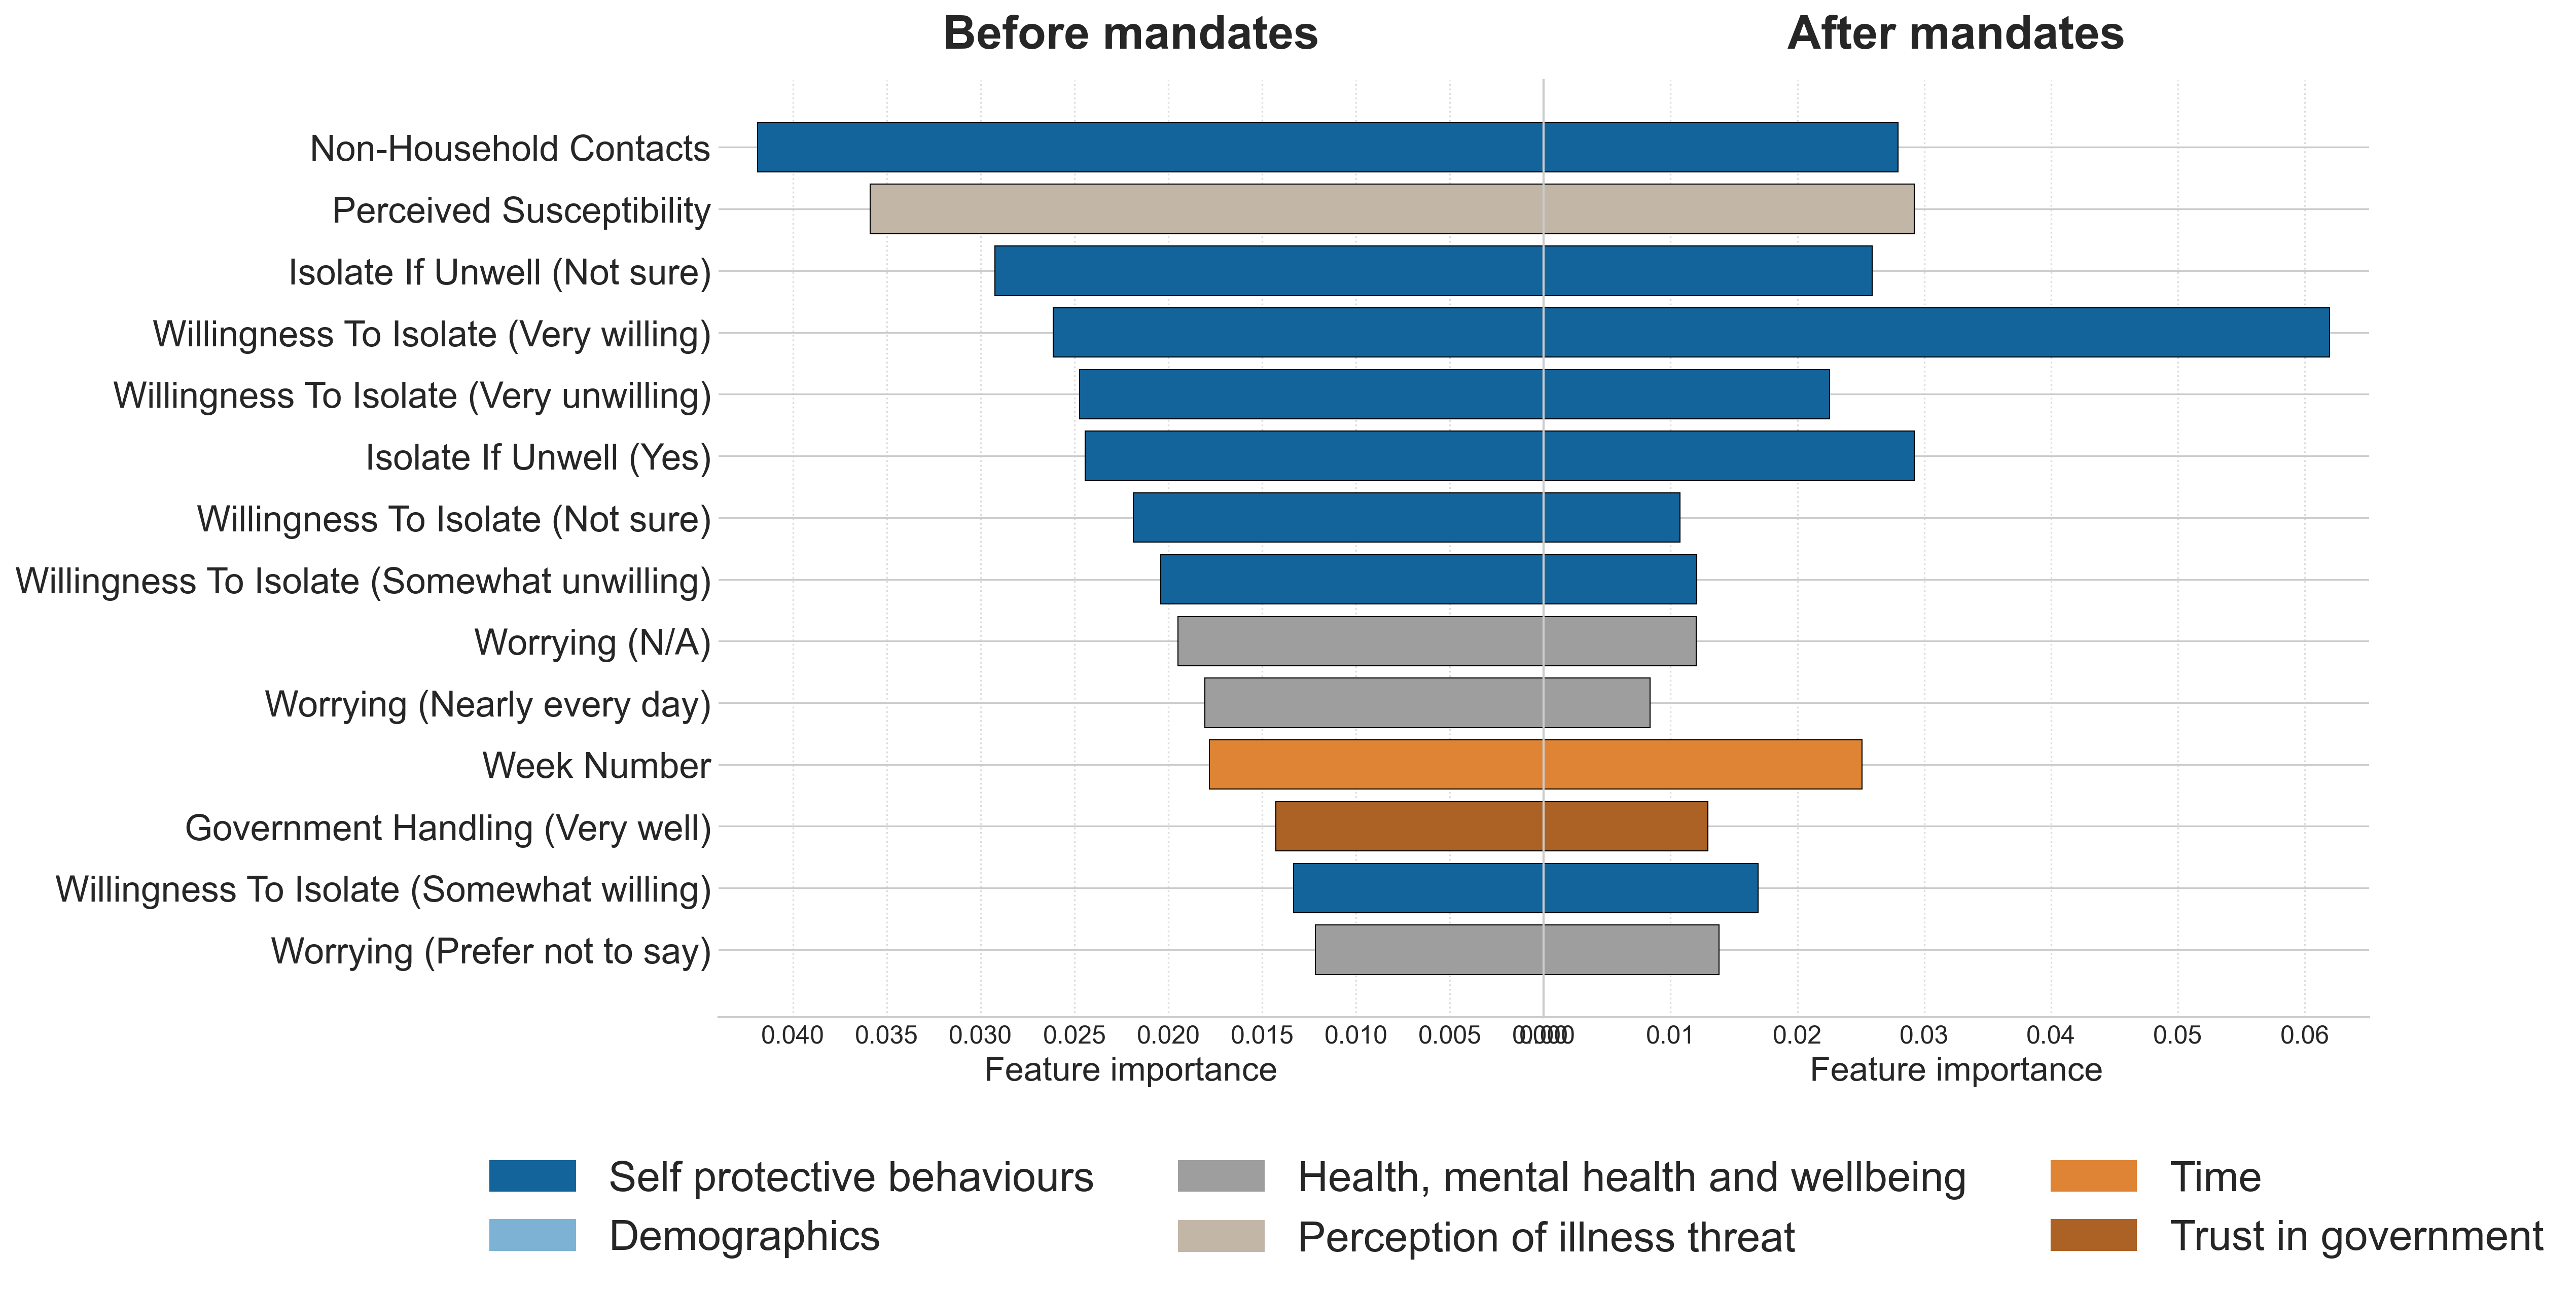

In [28]:
def plot_feature_importance(model_before, model_after, algo="rf", title_prefix="Face mask wearing", top_n=10):
    df_before = get_feature_importances(model_before, algo)
    df_after = get_feature_importances(model_after, algo)
    
    if df_before is None or df_after is None:
        print(f"Skipping plot: Missing model files for {algo} ({model_before}/{model_after}).")
        return

    top_before = df_before.sort_values(by='Importance', ascending=False).head(top_n)['Feature']
    top_after = df_after.sort_values(by='Importance', ascending=False).head(top_n)['Feature']
    union_features = list(set(top_before).union(set(top_after)))
    
    df_b = df_before[df_before['Feature'].isin(union_features)].set_index('Feature')
    df_a = df_after[df_after['Feature'].isin(union_features)].set_index('Feature')
    
    plot_df = pd.DataFrame(index=union_features)
    plot_df['Imp_B'] = df_b['Importance']
    plot_df['Imp_A'] = df_a['Importance']
    plot_df = plot_df.fillna(0) 
    
    plot_df = plot_df.sort_values(by='Imp_B', ascending=True)
    
    colors = [CATEGORY_COLORS.get(get_feature_category(f), '#333333') for f in plot_df.index]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
    fig.patch.set_facecolor('white')
    fig.subplots_adjust(wspace=0) 
    
    y_pos = np.arange(len(plot_df))
    
    # Before Mandates
    ax1.barh(y_pos, plot_df['Imp_B'], color=colors, edgecolor='black', linewidth=0.5)
    ax1.set_title("Before mandates", fontsize=22, fontweight='bold', pad=15)
    ax1.set_xlabel("Feature importance", fontsize=16)
    ax1.invert_xaxis() 
    ax1.grid(axis='x', linestyle=':', alpha=0.7)
    ax1.spines['top'].set_visible(False)
    ax1.spines['left'].set_visible(False) 
    
    #After Mandates
    ax2.barh(y_pos, plot_df['Imp_A'], color=colors, edgecolor='black', linewidth=0.5)
    ax2.set_title("After mandates", fontsize=22, fontweight='bold', pad=15)
    ax2.set_xlabel("Feature importance", fontsize=16)
    ax2.grid(axis='x', linestyle=':', alpha=0.7)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False) 
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(plot_df.index, fontsize=17)
    
    legend_handles = {cat: plt.Rectangle((0,0),1,1, color=color) 
                      for cat, color in CATEGORY_COLORS.items() if cat != 'Unknown'}
    fig.legend(legend_handles.values(), legend_handles.keys(), 
               loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=20)
        
    plt.savefig(FIG_DIR / f"{model_before.replace('a','')}_{algo}.png", dpi=300, bbox_inches='tight')
    plt.show()


plot_feature_importance("model_1a", "model_1b", algo="rf", title_prefix="Face Mask Wearing")
plot_feature_importance("model_1a", "model_1b", algo="xgboost", title_prefix="Face Mask Wearing")
plot_feature_importance("model_2a", "model_2b", algo="rf", title_prefix="General Protective Behaviours")
plot_feature_importance("model_2a", "model_2b", algo="xgboost", title_prefix="General Protective Behaviours")

### Overall Performance Bar Chart
Quick bar chart summarizing the mean roc auc across the board. an easy visual to show which architecture is generally outperforming the baseline across all data scenarios.

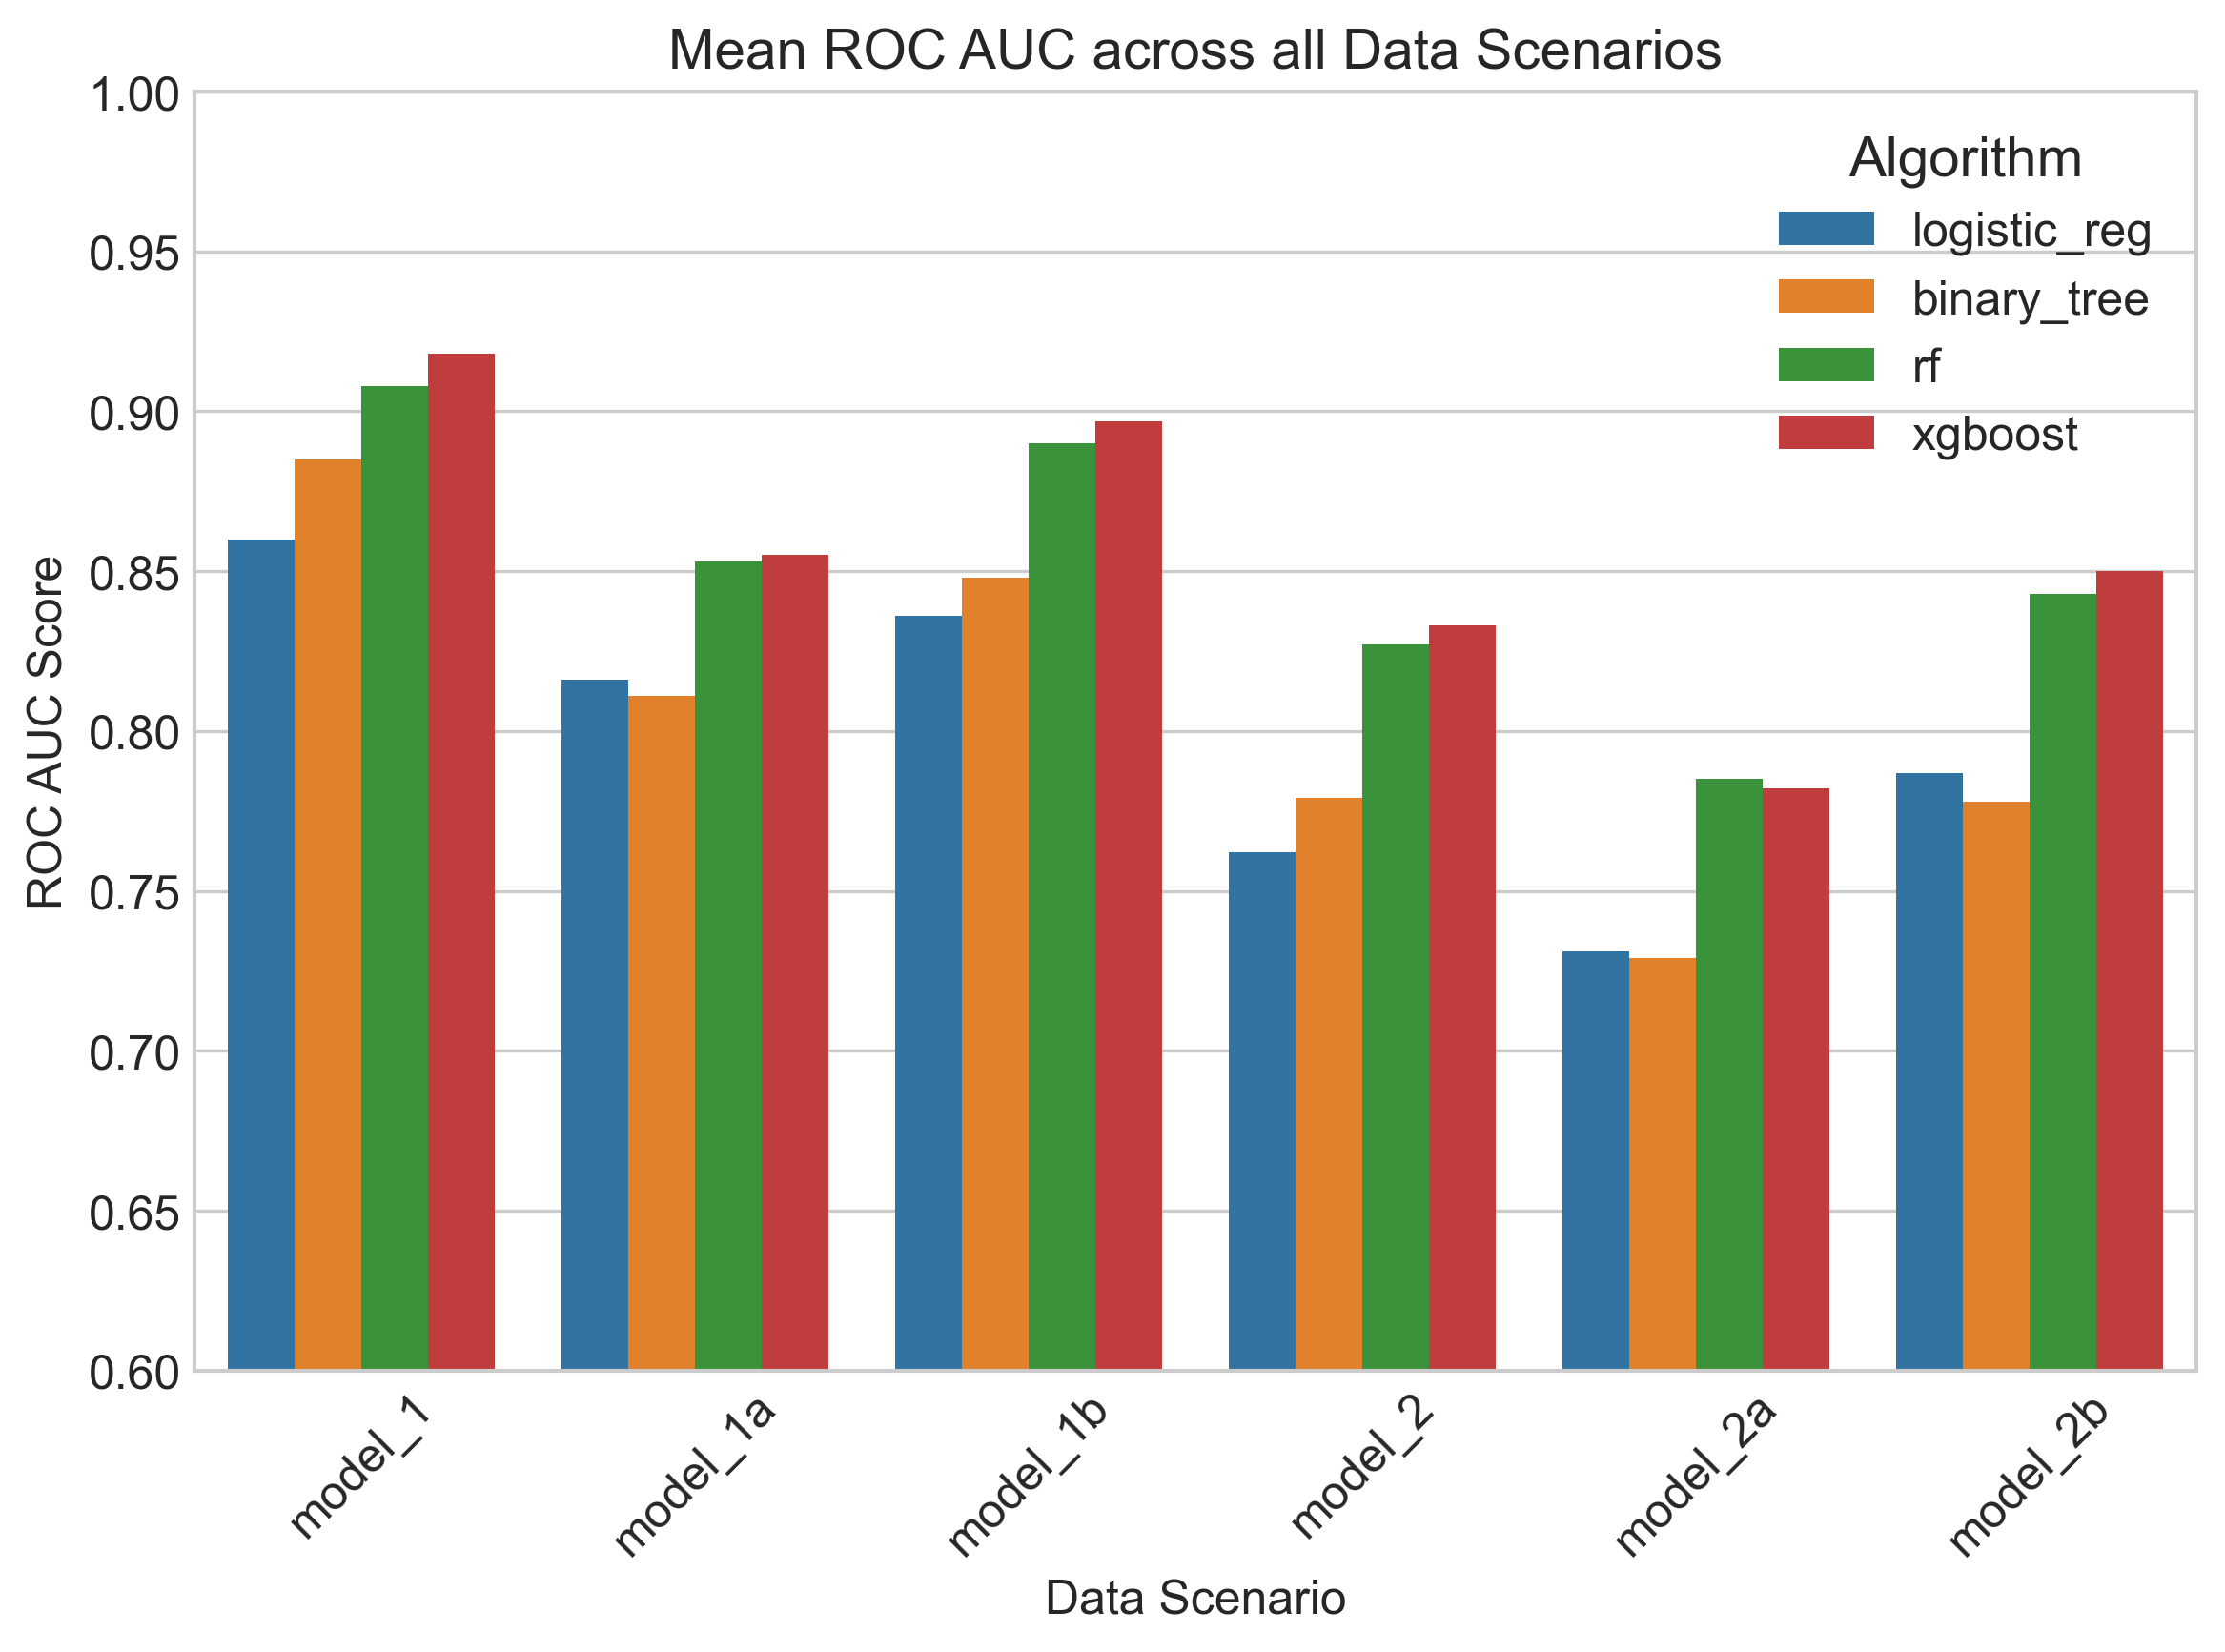

In [29]:
def plot_overall_performance():
    csv_path = RESULTS_DIR / "final_all_models_gridsearch_metrics.csv"
    if csv_path.exists():
        df_metrics = pd.read_csv(csv_path)

       
        df_metrics['roc_auc_numeric'] = df_metrics['roc_auc'].str.split(' ').str[0].astype(float)

        plt.figure(figsize=(8, 6))
        
        sns.barplot(data=df_metrics, x='model_number', y='roc_auc_numeric', hue='model_type')
        
        plt.ylim(0.6, 1.0)
        plt.title("Mean ROC AUC across all Data Scenarios", fontsize=14)
        plt.xlabel("Data Scenario", fontsize=12)
        plt.ylabel("ROC AUC Score", fontsize=12)
        plt.xticks(rotation=45)
        plt.legend(loc='upper right', title='Algorithm')

        plt.tight_layout()
        plt.savefig(FIG_DIR / "Overall_Performance_AUC.png", dpi=300)
        plt.show()

plot_overall_performance()